# California Housing Price Prediction: A Machine Learning Pipeline

## Executive Summary
This notebook presents a complete supervised regression pipeline to predict median house values using the California Census Housing dataset.

## Data Dictionary
- **longitude**: Decimal longitude of the census block group centroid.

- **latitude**: Decimal latitude of the census block group centroid.

- **housing_median_age**: Median age of housing units in the block group (years).

- **total_rooms**: Total number of rooms across all households in the block group.

- **total_bedrooms**: Total number of bedrooms across all households (207 missing values).

- **population**: Total population residing in the census block group.

- **households**: Total number of household units in the census block group.

- **median_income**: Median household income in tens of thousands of USD (range: 0.5 – 15.0).

- **median_house_value**: TARGET VARIABLE — Median house value in USD (range: $14,999 – $500,001).

- **ocean_proximity**: Categorical proximity to ocean.

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Build a Machine Learning Model

In [3]:
df = pd.read_csv("./cleaned_housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


## 1. Feature Engineering

In [4]:
# Create new features from existing ones.

df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

## 2. Train-Test Split

In [5]:
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

In [6]:
# split dataset into train and test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Preprocessing Pipeline

In [7]:
numerical_columns = X_train.select_dtypes(include=[np.number]).columns.to_list()
categorical_columns = X_train.select_dtypes(exclude=[np.number]).columns.to_list()

print(numerical_columns)
print(categorical_columns)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
['ocean_proximity']


In [8]:
numerical_transformer = Pipeline(
    steps =[
        ('imputer', SimpleImputer(strategy="median")),
        ('scaler', StandardScaler())
    ]
)


categorical_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy="most_frequent")),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_columns),
        ('num', numerical_transformer, numerical_columns)
    ]
)

### Linear Regression

In [9]:
linear_reg = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', LinearRegression())
    ]
)

In [10]:
# train the model

linear_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income',
                                                   'rooms_per_household',
                                                   'bedrooms_per_room',
                                                   'population_per_household'])])),
                ('model', LinearRegression())])

In [11]:
# Train Score

train_score = linear_reg.score(X_train, y_train)
test_score = linear_reg.score(X_test, y_test)

print("Training Score: {:.2f}%".format(train_score * 100))
print("Testing Score: {:.2f}%".format(test_score * 100))

Training Score: 65.82%
Testing Score: 59.70%


In [12]:
# Large gap → likely overfitting. Small gap → better generalization.
gap = train_score - test_score
print("Gap Performance: {:.2f}%".format(gap * 100))

Gap Performance: 6.12%


In [13]:
# Evaluate

y_pred = linear_reg.predict(X_test)
y_pred

array([ 61463.74466641, 121631.21809998, 267594.25389059, ...,
       447837.04647878, 117275.9214608 , 185597.46125194])

In [14]:
r2_score(y_test, y_pred)

0.5970176824350766

In [16]:
root_mean_squared_error(y_test, y_pred)

72668.53837868222

## Lasso

In [17]:
lasso_model = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', Lasso())
    ]
)

In [18]:
lasso_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.113e+12, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income',
                                                   'rooms_per_household',
                                                   'bedrooms_per_room',
                                                   'population_per_household'])])),
                ('model', Lasso())])

In [19]:
y_pred = lasso_model.predict(X_test)

In [20]:
r2_score(y_test, y_pred)

0.597008538436371

## Together

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "linear": LinearRegression(),
    "ridge": Ridge(),
    "lasso": Lasso(),
    "rf": RandomForestRegressor(random_state=42),
    "gbr": GradientBoostingRegressor(random_state=42)
}

In [22]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', model)
    ])

## 4. Model Evaluation

In [23]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    results[name] = {
        "RMSE": root_mean_squared_error(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }

results

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.113e+12, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


{'linear': {'RMSE': 72668.53837868222,
  'MAE': 50888.66001572007,
  'R2': 0.5970176824350766},
 'ridge': {'RMSE': 72677.92147403222,
  'MAE': 50897.5787333989,
  'R2': 0.5969136080801059},
 'lasso': {'RMSE': 72669.36282832002,
  'MAE': 50890.015722862045,
  'R2': 0.597008538436371},
 'rf': {'RMSE': 50417.00944696259,
  'MAE': 32373.82379844961,
  'R2': 0.8060243112049383},
 'gbr': {'RMSE': 53510.25144610543,
  'MAE': 36491.3933740845,
  'R2': 0.7814921099160049}}

## Manual Tuning

In [31]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', RandomForestRegressor(n_estimators=10, criterion='absolute_error', 
                                        max_features='sqrt', min_samples_leaf=10, random_state=42))
    ]
)

In [32]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income',
                                                   'rooms_per_household',
                                                   'bedrooms_per_room',
                                                   'population_per_household'])])),
                ('model',
                 RandomForestRegressor(criterion='absolute_error',
                                       max_features='sqrt', min_samples_leaf=10,
                                       n_estimators=10, random_state=42))])

In [33]:
y_pred = random_forest_model.predict(X_test)

In [34]:
r2_score(y_test, y_pred)

0.7837612719736196

Exception ignored in: <function ResourceTracker.__del__ at 0x105e25b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [ ]:
## 5. Hyperparameter tuning with RandomizedSearchCV

In [65]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor


random_grid = {
    'model__n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=1)],
    'model__max_depth': [int(x) for x in np.linspace(5,25,1)],
    # 'model__criterion': ['squared_error', 'absolute_error']
}


rf_random_cv = RandomizedSearchCV(
    estimator=pipelines["rf"],
    param_distributions=random_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    n_iter=1
)

rf_random_cv.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['ocean_proximity']),
                                                                              ('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['longitude',
                                                                                'latitude',
                                                                                'housing_median_age',
                                                                                'total_rooms',
                                                                                'total_bedrooms',
                                                                                'population',
                                                                                'households',
                                                                                'median_income',
                                                                                'rooms_per_household',
                                                                                'bedrooms_per_room',
                                                                                'population_per_household'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=1, n_jobs=-1,
                   param_distributions={'model__max_depth': [5],
                                        'model__n_estimators': [100]},
                   scoring='r2')

In [66]:
print(rf_random_cv.best_params_)
print(rf_random_cv.best_score_)

{'model__n_estimators': 100, 'model__max_depth': 5}
0.6968610964058352


In [67]:
rf_random_cv.best_estimator_

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income',
                                                   'rooms_per_household',
                                                   'bedrooms_per_room',
                                                   'population_per_household'])])),
                ('model', RandomForestRegressor(max_depth=5, random_state=42))])

In [68]:
predictions = rf_random_cv.predict(X_test)
predictions

array([ 78702.00356041, 104609.98442961, 318860.76153441, ...,
       487184.86237654, 104609.98442961, 194578.99208505])

In [69]:
mse = mean_squared_error(y_test, predictions)

print("R² Score: {:.2f}%".format(r2_score(y_test, predictions) * 100))
print("Mean Squared Error:", mse)

R² Score: 67.65%
Mean Squared Error: 4238528954.2817974


## 5. Hyperparameter tuning with GridSearchCV

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


# param_grid = {
#     'model__n_estimators': [100, 200],
#     'model__max_depth': [5, 10]
# }

param_grid = {
    'model__n_estimators': [rf_random_cv.best_params_['model__n_estimators']
                            # rf_random_cv.best_params_['model__n_estimators'] + 100,
                            # rf_random_cv.best_params_['model__n_estimators'] + 200
                            ],
    'model__max_depth': [rf_random_cv.best_params_['model__max_depth']
                        #  rf_random_cv.best_params_['model__max_depth'] + 5,
                        #  rf_random_cv.best_params_['model__max_depth'] + 10
                         ],
    # 'model__criterion': []     
}


rf_grid_cv = GridSearchCV(
    estimator=pipelines["rf"],
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity']),
                                                                        ('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income',
                                                                          'rooms_per_household',
                                                                          'bedrooms_per_room',
                                                                          'population_per_household'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5], 'model__n_estimators': [100]},
             scoring='r2')

In [72]:
print(rf_grid_cv.best_params_)
print(rf_grid_cv.best_score_)

{'model__max_depth': 5, 'model__n_estimators': 100}
0.6968610964058352


In [73]:
## Final Model

best_model = rf_grid_cv.best_estimator_

predictions = best_model.predict(X_test)
predictions

array([ 78702.00356041, 104609.98442961, 318860.76153441, ...,
       487184.86237654, 104609.98442961, 194578.99208505])

In [74]:
mse = mean_squared_error(y_test, predictions)

print("R² Score: {:.2f}%".format(r2_score(y_test, predictions) * 100))
print("Mean Squared Error:", mse)

R² Score: 67.65%
Mean Squared Error: 4238528954.2817974


In [75]:
import joblib

joblib.dump(best_model, 'house_price_model.pkl')

['house_price_model.pkl']

Exception ignored in: <function ResourceTracker.__del__ at 0x1112edb20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104d05b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1045b1b20>
Traceback (most recent call last

## 6. Feature Importance

In [76]:
best_model.named_steps

{'preprocess': ColumnTransformer(transformers=[('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('encoder',
                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                  ['ocean_proximity']),
                                 ('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['longitude', 'latitude', 'housing_median_age',
                                   'total_rooms', 'total_bedrooms', 'population',
                                   'households', 'median_income',
                                   'rooms_per_household', 'bedrooms_per_room'

In [77]:
cat_encoder = best_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['encoder']
encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_columns))
all_features = numerical_columns + encoded_cat_features

In [78]:
importances = best_model.named_steps['model'].feature_importances_

In [79]:
# Create a DataFrame for importances
feature_imp_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

In [80]:
feature_imp_df

,Feature,Importance
2,housing_median_age,0.000000
0,longitude,0.000005
3,total_rooms,0.000011
4,total_bedrooms,0.000022
8,rooms_per_household,0.000500
10,population_per_household,0.000811
11,ocean_proximity_<1H OCEAN,0.001377
13,ocean_proximity_ISLAND,0.001617
9,bedrooms_per_room,0.001833
14,ocean_proximity_NEAR BAY,0.001942



Feature importance plot saved as 'feature_importance.png'

Top Features by Importance:
                       Feature  Importance
12      ocean_proximity_INLAND    0.650770
1                     latitude    0.197739
15  ocean_proximity_NEAR OCEAN    0.108397
7                median_income    0.024710
6                   households    0.007895
5                   population    0.002373
14    ocean_proximity_NEAR BAY    0.001942
9            bedrooms_per_room    0.001833
13      ocean_proximity_ISLAND    0.001617
11   ocean_proximity_<1H OCEAN    0.001377
10    population_per_household    0.000811
8          rooms_per_household    0.000500
4               total_bedrooms    0.000022
3                  total_rooms    0.000011
0                    longitude    0.000005
2           housing_median_age    0.000000


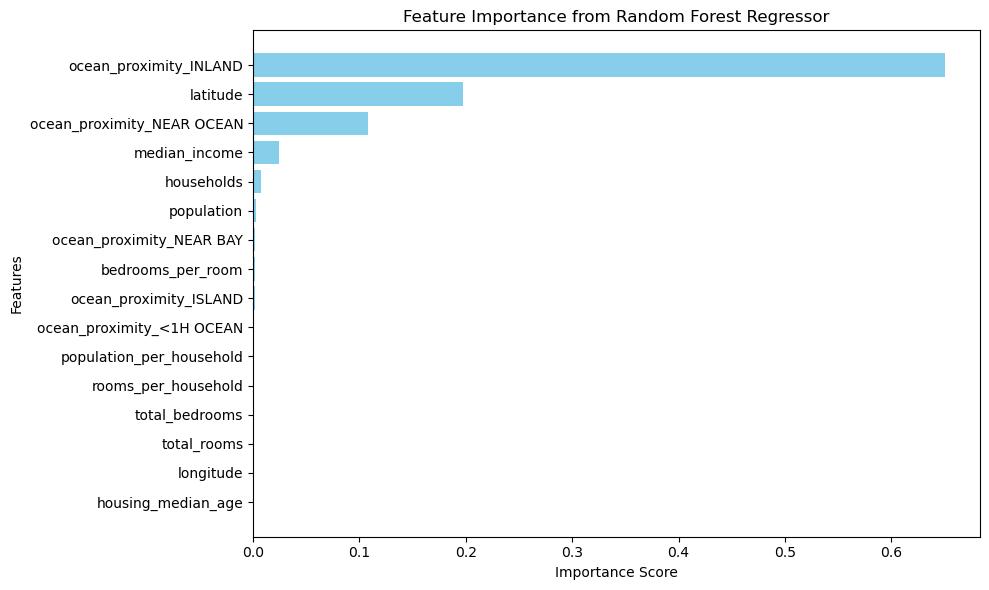

In [81]:
# Plot Feature Importance
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='skyblue')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Features')
ax.set_title('Feature Importance from Random Forest Regressor')
plt.tight_layout()
plt.savefig('feature_importance.png')
print("\nFeature importance plot saved as 'feature_importance.png'")

print("\nTop Features by Importance:")
print(feature_imp_df.sort_values(by='Importance', ascending=False))

## 7. Deployment

In [82]:
import pandas as pd
import numpy as np

# 1. Define your new data points (Simulating new real-world data)
# Note: We provide raw data just like the original CSV format.
new_houses_data = [
    {
        'longitude': -122.25,
        'latitude': 37.85,
        'housing_median_age': 40,
        'total_rooms': 1500,
        'total_bedrooms': 300,
        'population': 600,
        'households': 250,
        'median_income': 6.5,          # High income area
        'ocean_proximity': 'NEAR BAY'
    },
    {
        'longitude': -119.50,
        'latitude': 36.00,
        'housing_median_age': 15,
        'total_rooms': 3000,
        'total_bedrooms': np.nan,      # Testing the imputer with a missing value!
        'population': 1800,
        'households': 550,
        'median_income': 2.1,          # Lower income inland area
        'ocean_proximity': 'INLAND'
    }
]

# 2. Convert the new data into a Pandas DataFrame
X_new = pd.DataFrame(new_houses_data)

# 3. Apply the exact same Feature Engineering steps we used during training
X_new['rooms_per_household'] = X_new['total_rooms'] / X_new['households']
X_new['bedrooms_per_room'] = X_new['total_bedrooms'] / X_new['total_rooms']
X_new['population_per_household'] = X_new['population'] / X_new['households']

# 4. Use the saved best_model pipeline to predict
# (Assuming 'best_model' variable is active in your environment from the previous step)
predictions = best_model.predict(X_new)

# 5. Output the results cleanly
print("--- Model Predictions for New Data ---")
for i, pred in enumerate(predictions):
    print(f"House {i+1} ({X_new.loc[i, 'ocean_proximity']}): Estimated Value = ${pred:,.2f}")

--- Model Predictions for New Data ---
House 1 (NEAR BAY): Estimated Value = $377,529.60
House 2 (INLAND): Estimated Value = $78,918.47
